Now we will perform the Exploratory data analysis on the features against the target variables & also replace the missing values-

1. encode all the variables

2. eda of in which month customers were churning the most? any seasonality.

3. PCA to find correlation of the variable - part of feature engineering.

4. Replace UsageData & BillingAmount NaNs with the mean of contractType of that column.

5. Binning of the demographic columns, age & Income.

6. assign churn risk score probability from 0-100%.

7. Binning of churn prediction

In [171]:
import sys, os, glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.impute import KNNImputer
# importing nessaary util functions
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), ".")))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [172]:
from utils.utils import plot_feature_comparison, find_best_k_for_knn_imputer

In [173]:
# processed_df_path should go in the config.yaml
processed_df_path = "../data/processed/churn_data_processed.csv"
df = pd.read_csv(processed_df_path)

In [174]:
df.dtypes

UsageData                      float64
BillingAmount                  float64
PaymentHistory                   int64
CustomerServiceInteractions      int64
Complaints                       int64
PromotionsReceived               int64
ContractType                     int64
ContractDuration                 int64
Age                              int64
Gender                           int64
Income                           int64
HouseholdSize                    int64
is_churned                       int64
Month                            int64
dtype: object

In [175]:
df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,0,57732,2,0,1
1,NaN,176.144725,1,1,0,2,1,12,51,0,84085,3,0,1
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,0,1
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,0,1
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,0,1


#### Plotting relationship between behaviour of churned users vs exisiting users

/Users/akshaysharma/Documents/forecast_customer_churn/forecasting_customer_churn/utils/utils.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_avg, x=x_col, y=y_col, palette=palette)


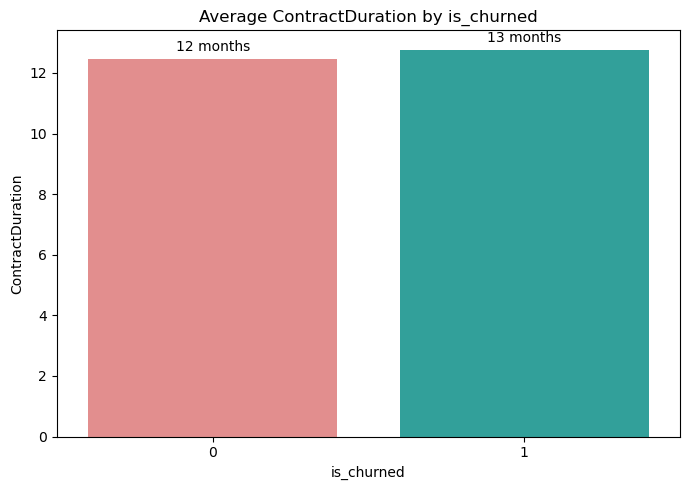

In [176]:
#plotting relationship between different behaviour of churned users
plot_feature_comparison(df    = df,
                        x_col = 'is_churned',
                        y_col = 'ContractDuration')

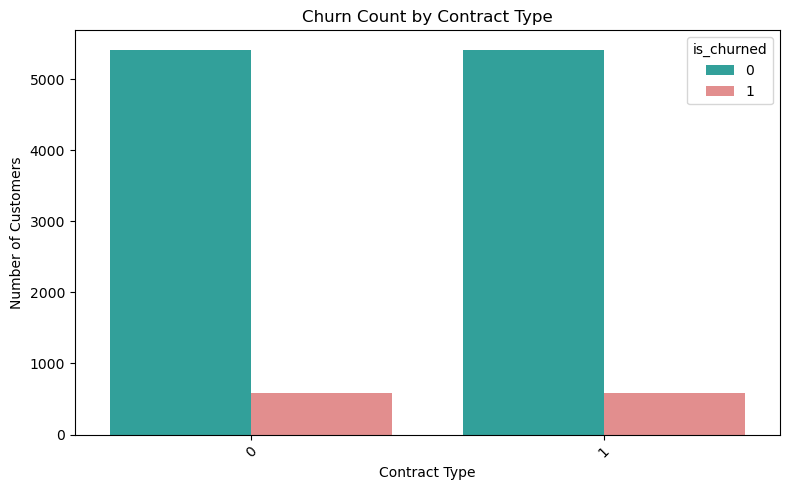

In [177]:
# Side-by-side bar plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ContractType', hue='is_churned', palette=['#20B2AA', '#F08080'])
plt.title("Churn Count by Contract Type")
plt.ylabel("Number of Customers")
plt.xlabel("Contract Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [178]:
df['ContractType'].value_counts()

ContractType
1    6002
0    5998
Name: count, dtype: int64

In [179]:
df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
0,880.922970,NaN,1,2,0,0,1,16,18,0,57732,2,0,1
1,NaN,176.144725,1,1,0,2,1,12,51,0,84085,3,0,1
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,0,1
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,0,1
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,0,1


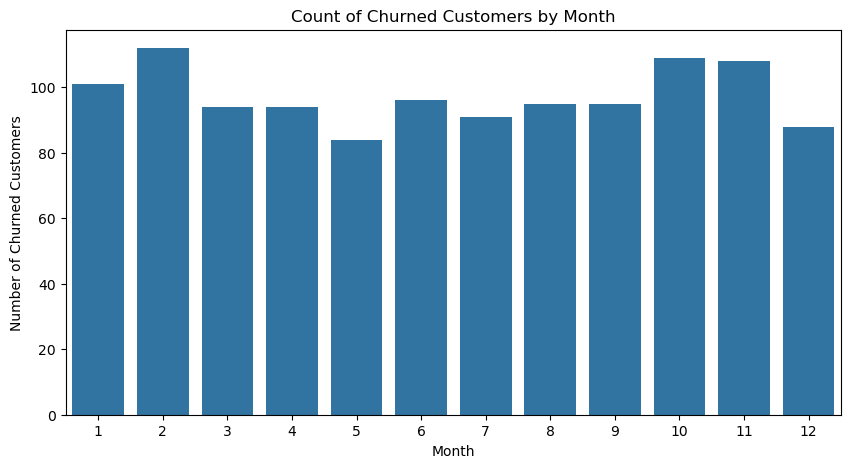

In [180]:
# Filter for churned customers only
churned_df = df[df['is_churned'] == 1]

# Plot count of churned customers by month
plt.figure(figsize=(10, 5))
sns.countplot(data=churned_df, x='Month')
plt.title("Count of Churned Customers by Month")
plt.xlabel("Month")
plt.ylabel("Number of Churned Customers")
plt.show()

In [181]:
churned_df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
16,261.663414,NaN,1,4,1,0,1,10,58,1,90962,5,1,1
46,NaN,82.854081,0,4,0,3,1,17,42,1,99177,1,1,1
49,362.151951,NaN,1,3,2,0,1,20,58,1,73835,4,1,1
50,916.450499,36.167692,1,3,1,0,1,9,68,0,72518,2,1,1
64,193.085615,97.691614,1,0,2,1,0,2,21,0,83490,5,1,1


### Replace the missing values in usageData & BillingAmount
In order to replace the missing values we are first using simple median to replace the NaNs, 

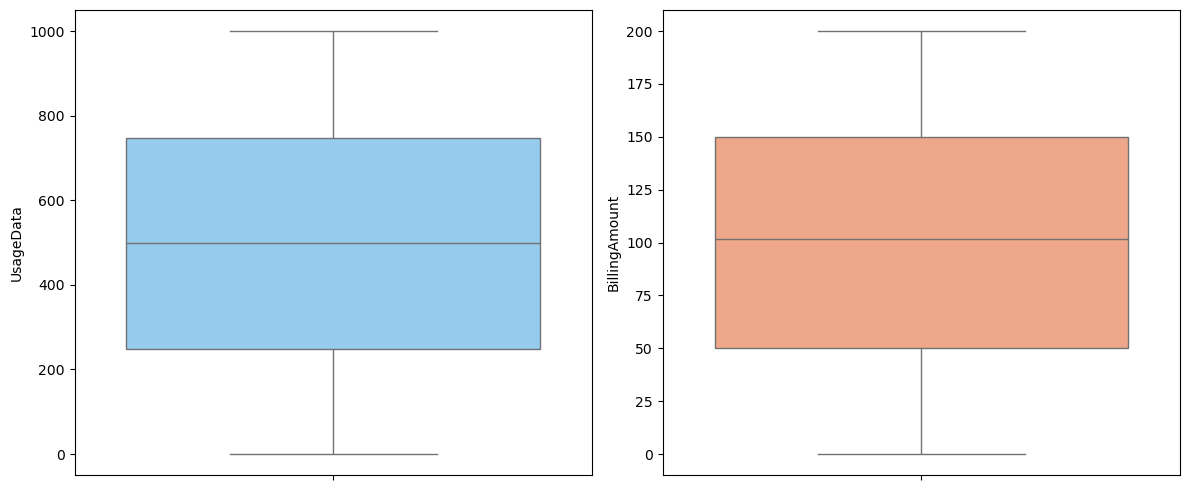

In [182]:
plt.figure(figsize=(12, 5))

# UsageData with log scale
plt.subplot(1, 2, 1)
sns.boxplot(data=df, y='UsageData', color='#87CEFA')

# BillingAmount with log scale
plt.subplot(1, 2, 2)
sns.boxplot(data=df, y='BillingAmount', color='#FFA07A')

plt.tight_layout()
plt.show()

In [183]:
#lets replace the missing values in billing & usage data with group median of contractType
df_feature_eng = df.copy()
df_feature_eng['UsageData'] = df_feature_eng.groupby('ContractType')['UsageData'].transform(lambda x: x.fillna(x.median()))
df_feature_eng['BillingAmount'] = df_feature_eng.groupby('ContractType')['BillingAmount'].transform(lambda x: x.fillna(x.median()))

# Confirm missing values are handled
print(df_feature_eng[['UsageData', 'BillingAmount']].isnull().sum())

UsageData        0
BillingAmount    0
dtype: int64


### Correlation of churn with individual variables

In [184]:
# now we will plot all the continuous variables against churn column to notice the relationship of churn with individual variables
df_feature_eng[df_feature_eng['is_churned'] == 1].describe()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
count,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.000000,1167.0,1167.000000
mean,508.985632,99.111682,0.812339,2.542416,1.010283,1.487575,0.501285,12.769494,43.261354,0.505570,73073.483290,3.163668,1.0,6.482434
std,253.191513,51.873322,0.390608,1.679166,0.830320,1.127228,0.500213,6.830526,15.039664,0.500183,23328.402875,1.510892,0.0,3.500722
min,0.866777,0.019002,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000,25874.000000,1.000000,1.0,1.000000
25%,343.371638,62.451144,1.000000,1.000000,0.000000,0.000000,0.000000,7.000000,31.000000,0.000000,53033.500000,2.000000,1.0,3.000000
50%,504.248065,100.441977,1.000000,3.000000,1.000000,1.000000,1.000000,13.000000,44.000000,1.000000,73917.000000,3.000000,1.0,7.000000
75%,680.727078,136.044620,1.000000,4.000000,2.000000,3.000000,1.000000,19.000000,56.000000,1.000000,92341.000000,4.000000,1.0,10.000000
max,999.875654,199.804649,1.000000,6.000000,2.000000,3.000000,1.000000,24.000000,69.000000,1.000000,118248.000000,9.000000,1.0,12.000000


In [185]:
# now we will plot all the continuous variables against churn column to notice the relationship of churn with individual variables
df_feature_eng[df_feature_eng['is_churned'] == 0].describe()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month
count,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.000000,10833.0,10833.000000
mean,499.902343,100.851717,0.795901,2.481030,1.011816,1.482138,0.500046,12.461460,43.492015,0.503923,72972.775778,3.106434,0.0,6.501892
std,258.066079,51.516337,0.403060,1.702601,0.814524,1.127031,0.500023,6.956967,14.907710,0.500008,23491.946960,1.524913,0.0,3.447086
min,0.031196,0.005248,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000,25451.000000,1.000000,0.0,1.000000
25%,306.963452,63.424468,1.000000,1.000000,0.000000,0.000000,0.000000,6.000000,31.000000,0.000000,53103.000000,2.000000,0.0,4.000000
50%,496.286902,101.870575,1.000000,2.000000,1.000000,1.000000,1.000000,12.000000,43.000000,1.000000,73161.000000,3.000000,0.0,6.000000
75%,686.350275,138.080288,1.000000,4.000000,2.000000,2.000000,1.000000,19.000000,56.000000,1.000000,92733.000000,4.000000,0.0,9.000000
max,999.957592,199.976431,1.000000,6.000000,2.000000,3.000000,1.000000,24.000000,69.000000,1.000000,120606.000000,9.000000,0.0,12.000000


In [186]:
df_feature_eng.dtypes

UsageData                      float64
BillingAmount                  float64
PaymentHistory                   int64
CustomerServiceInteractions      int64
Complaints                       int64
PromotionsReceived               int64
ContractType                     int64
ContractDuration                 int64
Age                              int64
Gender                           int64
Income                           int64
HouseholdSize                    int64
is_churned                       int64
Month                            int64
dtype: object

In [187]:
numeric_cols = df.select_dtypes(include=['number']).drop(columns=['is_churned']).columns
numeric_cols

Index(['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'Month'],
      dtype='object')

/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_74234/1206022490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, palette=['#20B2AA', '#F08080'])
/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_74234/1206022490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, palette=['#20B2AA', '#F08080'])
/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_74234/1206022490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y=col, pal

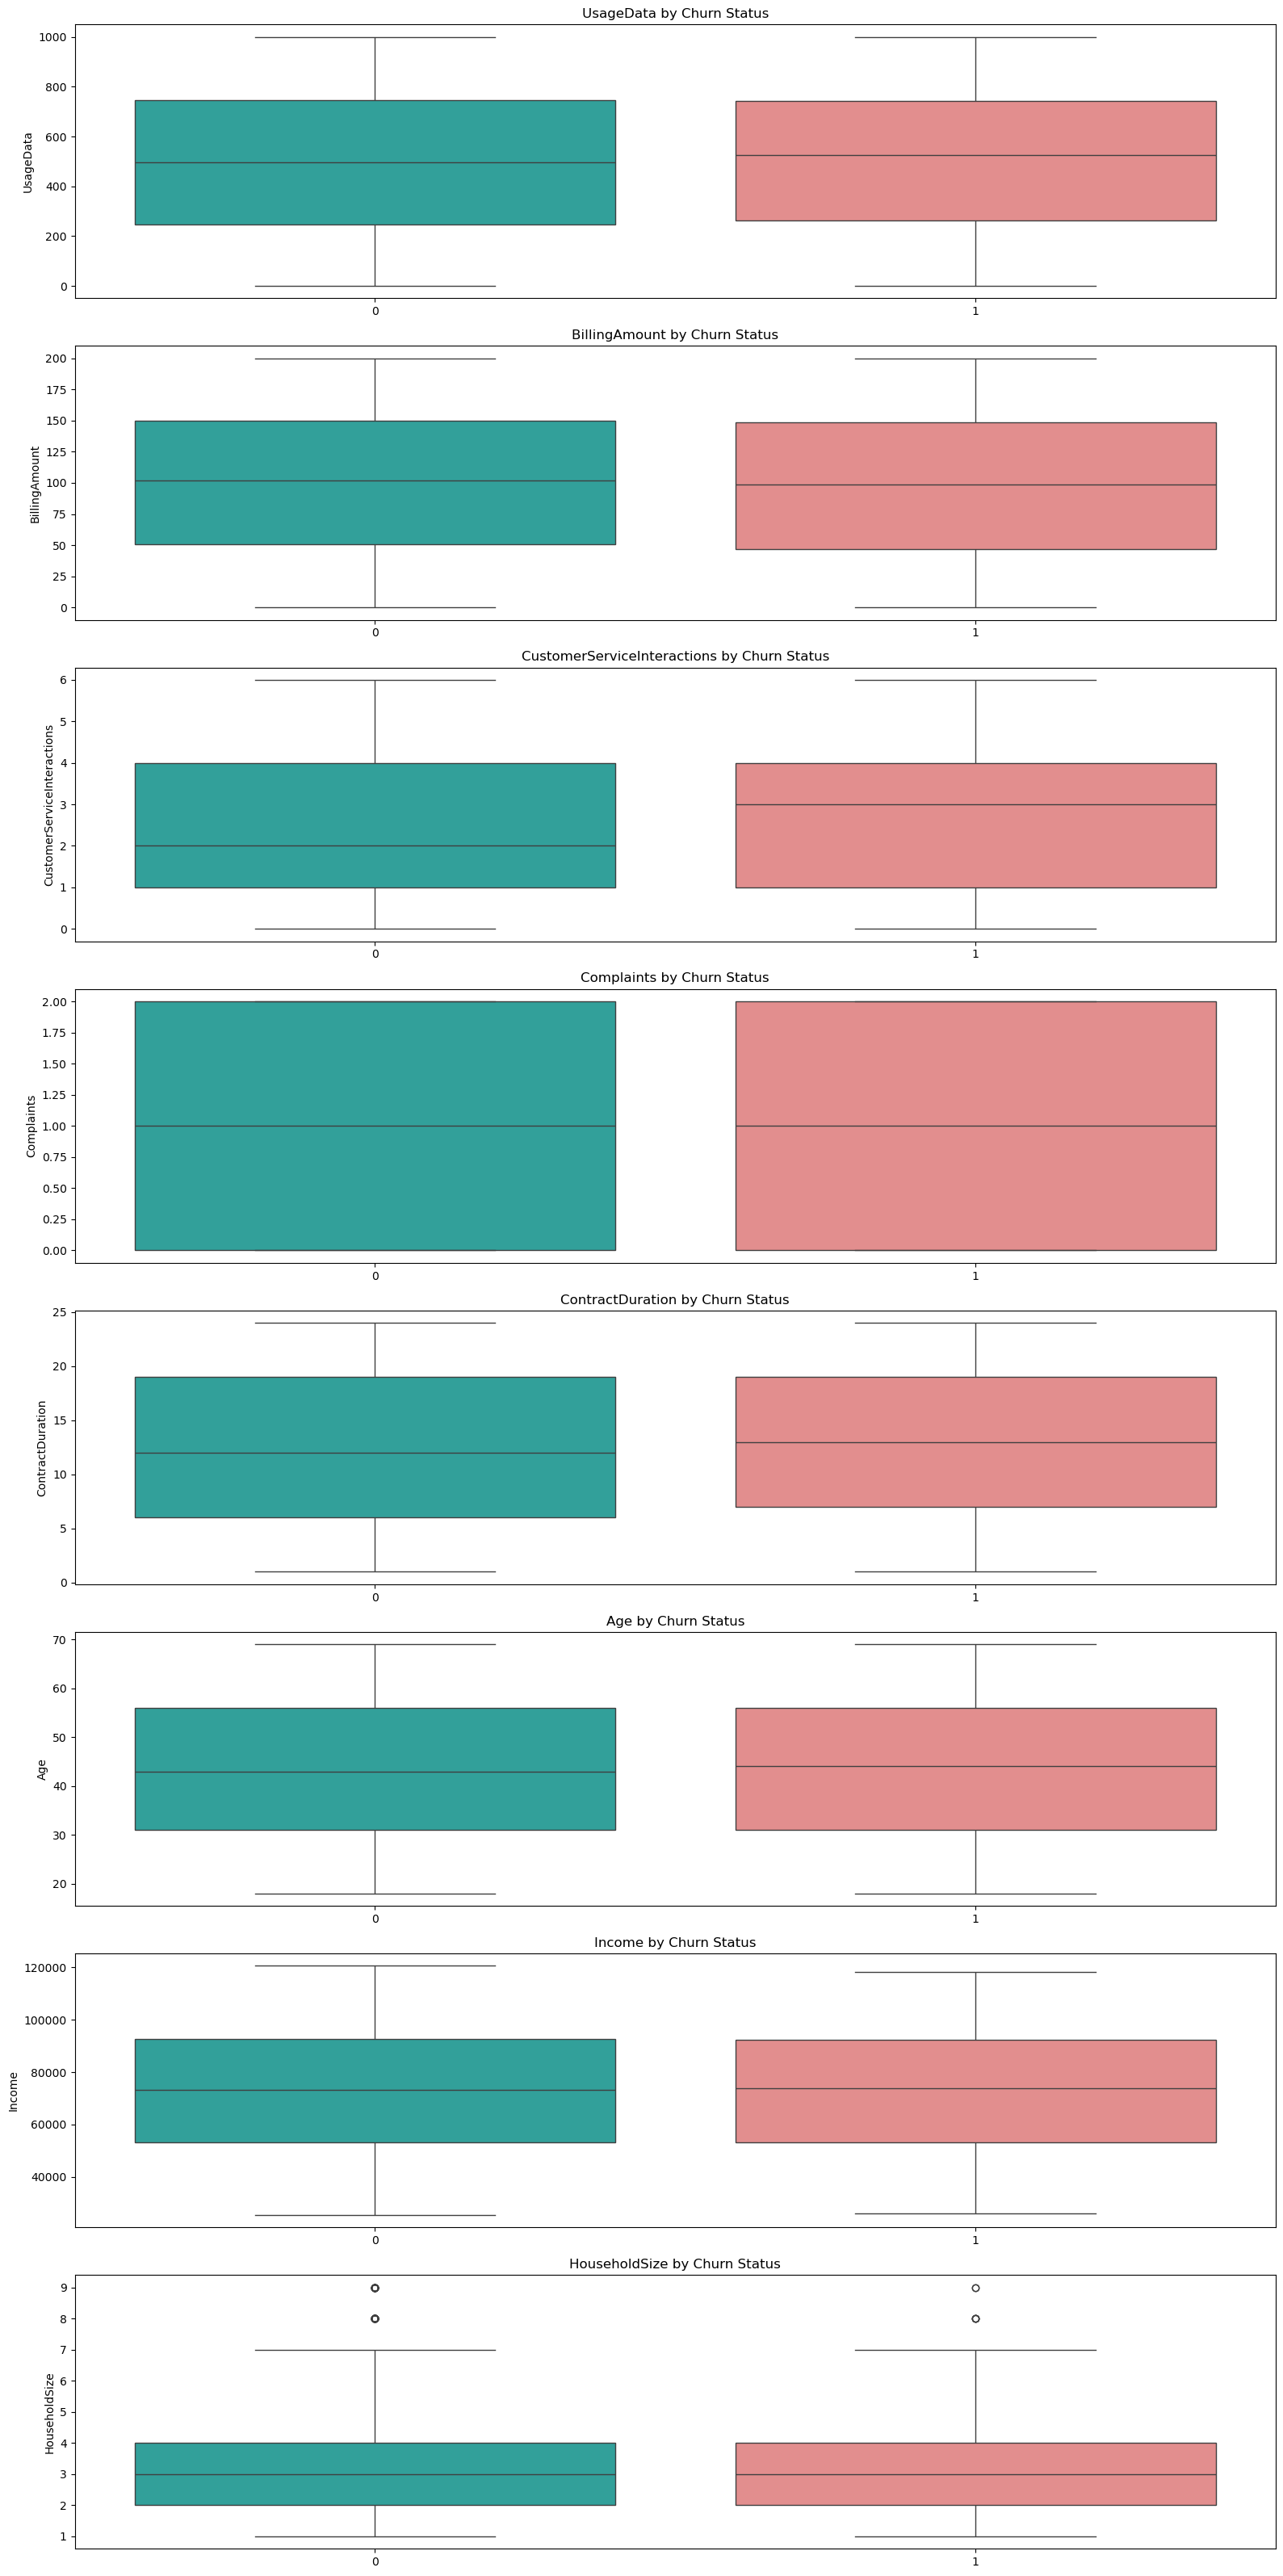

In [188]:
# Filter only numeric columns (excluding the target)
numeric_cols = ['UsageData', 'BillingAmount', 'CustomerServiceInteractions', 'Complaints', 'ContractDuration', 'Age', 'Income', 'HouseholdSize']

# Plot
plt.figure(figsize=(16, len(numeric_cols) * 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 1, i + 1)
    sns.boxplot(data=df, x='is_churned', y=col, palette=['#20B2AA', '#F08080'])
    plt.title(f'{col} by Churn Status')
    plt.xlabel('')
    plt.tight_layout()
plt.show()

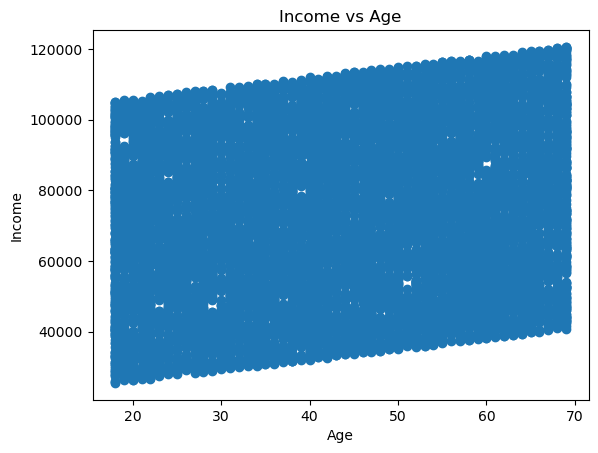

In [189]:
# income vs age
plt.scatter(df['Age'], df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income vs Age')
plt.show()

#### let's do correlation heatmap

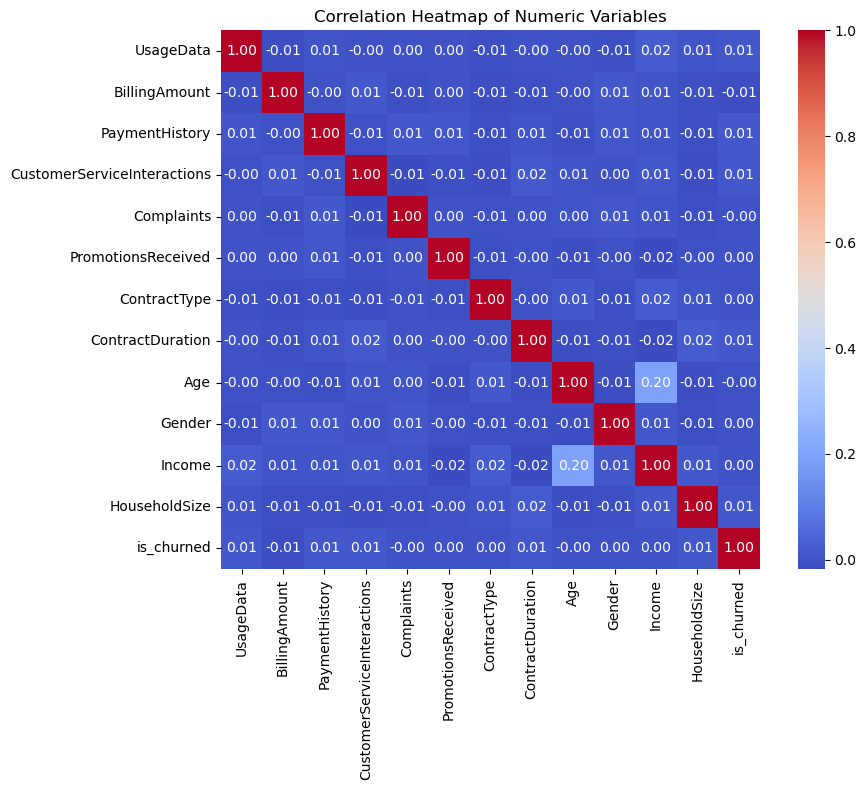

In [190]:
# let's drop month column as of now
corr_df = df_feature_eng.drop(columns=['Month'])

# Compute correlation matrix (numeric variables only)
corr = corr_df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

Due to weak correlation of each variable let's try to introduce some composite variables such as-

1. *CostPerUnit* - Feature would tell us if the user is getting a good deal in thier contract & if costPerUnit is high they might consider churning
2. *HighEnergyUsers* - Feature would tell us if someone who have higher energy usage(above 75% quantile) & might be at risk of churning due to expansive bills.
3. *BilltoIncomeRatio* - Feature would help us understanding if a particular customer would be able to afford the electricity bill.
4. *shortTermContracts* - Generally, short term contracts users have higher probability of churning.

In [191]:
df_feature_eng['HighUsageFlag'] = (df_feature_eng['UsageData'] > df_feature_eng['UsageData'].quantile(0.75)).astype(int)

In [192]:
df_feature_eng['CostPerUnit'] = df_feature_eng['BillingAmount'] / df_feature_eng['UsageData']
df_feature_eng['BilltoIncomeRatio'] = df_feature_eng['Income'] / df_feature_eng['BillingAmount']

In [193]:
df_feature_eng['IsShortContractedCust'] = (df_feature_eng['ContractDuration'] <= 6).astype(int)

In [194]:
# 3. Engagement Score
df_feature_eng['EngagementScore'] = (df_feature_eng['CustomerServiceInteractions'] + df_feature_eng['PromotionsReceived'] - df_feature_eng['Complaints'])

In [195]:
df_feature_eng['CostPerUnit'].describe()

count    12000.000000
mean         0.901372
std         18.949044
min          0.000007
25%          0.115990
50%          0.202513
75%          0.352762
max       1741.996327
Name: CostPerUnit, dtype: float64

In [196]:
df_feature_eng[df_feature_eng['CostPerUnit'] > 10][df_feature_eng['is_churned'] == 1]

/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_74234/342456330.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_feature_eng[df_feature_eng['CostPerUnit'] > 10][df_feature_eng['is_churned'] == 1]


,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month,HighUsageFlag,CostPerUnit,BilltoIncomeRatio,IsShortContractedCust,EngagementScore
361,14.472296,175.324256,1,3,2,1,1,13,48,0,53743,1,1,1,0,12.114474,306.534882,0,2
3676,5.283032,100.441977,1,3,0,3,1,18,65,0,105659,1,1,4,0,19.012184,1051.940668,0,6
4356,3.395015,168.254981,1,0,2,2,1,12,58,0,106711,5,1,5,0,49.559426,634.221938,0,0
6183,5.680632,102.835230,1,4,2,2,0,24,41,1,57886,5,1,7,0,18.102778,562.900476,0,4
8475,0.866777,148.971212,0,4,0,1,0,20,57,1,87063,6,1,9,0,171.867925,584.428352,0,5
9792,10.043178,197.822052,0,5,2,2,1,1,20,0,90455,5,1,10,0,19.697156,457.254381,1,5
10532,4.651746,172.744036,0,3,2,0,1,2,54,0,37140,1,1,11,0,37.135308,215.000187,1,1
10614,10.089604,126.920495,1,1,1,0,1,17,29,0,28822,5,1,11,0,12.579334,227.087043,0,0
11984,4.987922,81.737015,0,3,0,3,0,5,42,0,42708,4,1,12,0,16.386986,522.505012,1,6


In [197]:
df_feature_eng.shape

(12000, 19)

In [198]:
# Assuming df is your working DataFrame (after imputation)
# You can add these interaction features directly:

# Income * Complaints — wealthier customers complaining more
df_feature_eng['Income_x_Complaints'] = df_feature_eng['Income'] * df_feature_eng['Complaints']

# BillingAmount * ContractDuration — total expected contract value
df_feature_eng['Billing_x_ContractLength'] = df_feature_eng['BillingAmount'] * df_feature_eng['ContractDuration']

# Gender * Complaints — gender-based complaint interaction
df_feature_eng['Gender_x_Complaints'] = df_feature_eng['Gender'] * df_feature_eng['Complaints']

# PaymentHistory * PromotionsReceived — effect of past payments vs. engagement attempts
df_feature_eng['Promo_x_PaymentHistory'] = df_feature_eng['PromotionsReceived'] * df_feature_eng['PaymentHistory']

# You can also square variables if you think the effect is non-linear
df_feature_eng['UsageData_squared'] = df_feature_eng['UsageData'] ** 2

# Age * Usage: do older customers use more or less power?
df_feature_eng['Age_x_Usage'] = df_feature_eng['Age'] * df_feature_eng['UsageData']

# Contract type (0 = fixed, 1 = variable) * interactions: dissatisfaction risk
df_feature_eng['ContractType_x_CSInteractions'] = df_feature_eng['ContractType'] * df_feature_eng['CustomerServiceInteractions']

# Billing * Income: financial pressure
df_feature_eng['Billing_x_Income'] = df_feature_eng['BillingAmount'] / (df_feature_eng['Income'] + 1)  # avoid division by zero

In [199]:
# cost per unit should not exceed 10 dollar as i think generally it is around 0.30/kw to 0.90/kw, data is definetly wrong if it has astronomical values like 17000
df_feature_eng = df_feature_eng[df_feature_eng['CostPerUnit'] < 10]

In [200]:
df_feature_eng.shape

(11920, 27)

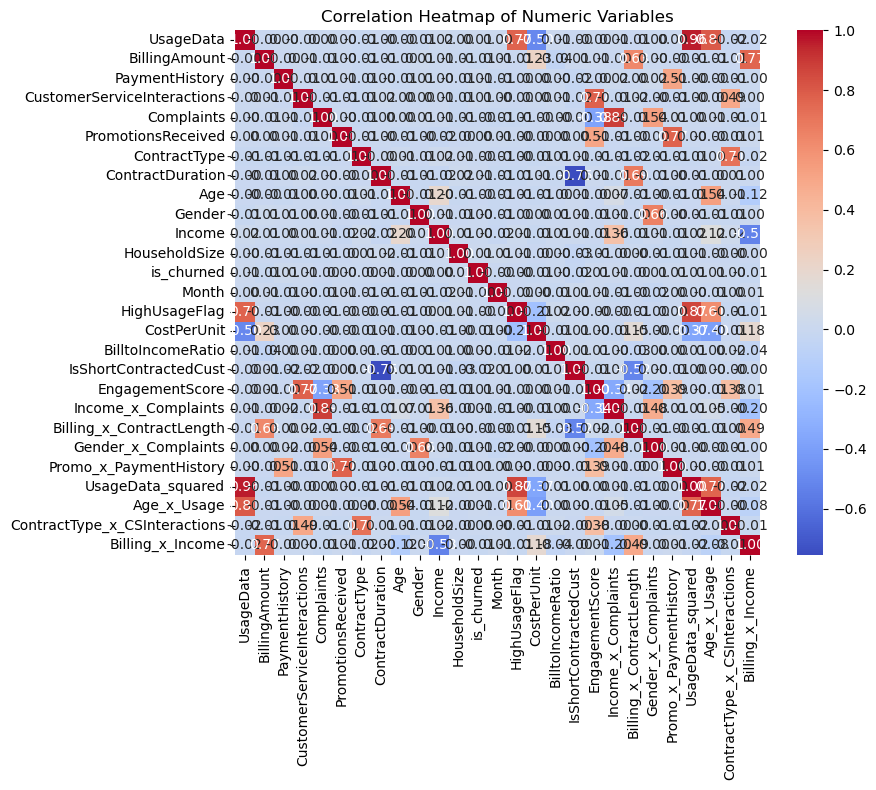

In [201]:
# Compute correlation matrix (numeric variables only)
corr = df_feature_eng.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [202]:
df_feature_eng.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,is_churned,Month,HighUsageFlag,CostPerUnit,BilltoIncomeRatio,IsShortContractedCust,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income
0,880.922970,100.441977,1,2,0,0,1,16,18,0,57732,2,0,1,1,0.114019,574.779608,0,2,0,1607.071626,0,0,776025.279639,15856.613466,2,0.001740
1,495.978553,176.144725,1,1,0,2,1,12,51,0,84085,3,0,1,0,0.355146,477.363145,0,3,0,2113.736702,0,2,245994.725453,25294.906224,1,0.002095
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,0,1,0,0.467310,356.221697,0,2,0,2185.352567,0,0,97196.287248,6547.027010,0,0.002807
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,0,1,0,0.254107,685.882448,0,6,72227,1368.967820,0,3,171737.946412,9531.493779,4,0.001458
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,0,1,0,0.213768,720.860481,0,6,75414,889.241423,2,3,59876.635355,10032.578135,0,0.001387


In [203]:
df_feature_eng.dtypes

UsageData                        float64
BillingAmount                    float64
PaymentHistory                     int64
CustomerServiceInteractions        int64
Complaints                         int64
PromotionsReceived                 int64
ContractType                       int64
ContractDuration                   int64
Age                                int64
Gender                             int64
Income                             int64
HouseholdSize                      int64
is_churned                         int64
Month                              int64
HighUsageFlag                      int64
CostPerUnit                      float64
BilltoIncomeRatio                float64
IsShortContractedCust              int64
EngagementScore                    int64
Income_x_Complaints                int64
Billing_x_ContractLength         float64
Gender_x_Complaints                int64
Promo_x_PaymentHistory             int64
UsageData_squared                float64
Age_x_Usage     

In [204]:
df_feature_eng.columns

Index(['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'is_churned', 'Month', 'HighUsageFlag', 'CostPerUnit',
       'BilltoIncomeRatio', 'IsShortContractedCust', 'EngagementScore',
       'Income_x_Complaints', 'Billing_x_ContractLength',
       'Gender_x_Complaints', 'Promo_x_PaymentHistory', 'UsageData_squared',
       'Age_x_Usage', 'ContractType_x_CSInteractions', 'Billing_x_Income'],
      dtype='object')

In [205]:
df_feature_eng.drop(columns=['Month'])
# Define the desired column order
desired_order = ['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'Month', 'HighUsageFlag', 'CostPerUnit',
       'BilltoIncomeRatio', 'IsShortContractedCust', 'EngagementScore',
       'Income_x_Complaints', 'Billing_x_ContractLength',
       'Gender_x_Complaints', 'Promo_x_PaymentHistory', 'UsageData_squared',
       'Age_x_Usage', 'ContractType_x_CSInteractions', 'Billing_x_Income', 'is_churned']
# Reorder DataFrame
df_feature_eng = df_feature_eng[desired_order]
print(df_feature_eng.columns)

Index(['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'Month', 'HighUsageFlag', 'CostPerUnit',
       'BilltoIncomeRatio', 'IsShortContractedCust', 'EngagementScore',
       'Income_x_Complaints', 'Billing_x_ContractLength',
       'Gender_x_Complaints', 'Promo_x_PaymentHistory', 'UsageData_squared',
       'Age_x_Usage', 'ContractType_x_CSInteractions', 'Billing_x_Income',
       'is_churned'],
      dtype='object')


In [206]:
df_feature_eng.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,Month,HighUsageFlag,CostPerUnit,BilltoIncomeRatio,IsShortContractedCust,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,is_churned
0,880.922970,100.441977,1,2,0,0,1,16,18,0,57732,2,1,1,0.114019,574.779608,0,2,0,1607.071626,0,0,776025.279639,15856.613466,2,0.001740,0
1,495.978553,176.144725,1,1,0,2,1,12,51,0,84085,3,1,0,0.355146,477.363145,0,3,0,2113.736702,0,2,245994.725453,25294.906224,1,0.002095,0
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,1,0,0.467310,356.221697,0,2,0,2185.352567,0,0,97196.287248,6547.027010,0,0.002807,0
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,1,0,0.254107,685.882448,0,6,72227,1368.967820,0,3,171737.946412,9531.493779,4,0.001458,0
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,1,0,0.213768,720.860481,0,6,75414,889.241423,2,3,59876.635355,10032.578135,0,0.001387,0


#### Principal Component Analysis

In [207]:
df_feature_eng.columns

Index(['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'Month', 'HighUsageFlag', 'CostPerUnit',
       'BilltoIncomeRatio', 'IsShortContractedCust', 'EngagementScore',
       'Income_x_Complaints', 'Billing_x_ContractLength',
       'Gender_x_Complaints', 'Promo_x_PaymentHistory', 'UsageData_squared',
       'Age_x_Usage', 'ContractType_x_CSInteractions', 'Billing_x_Income',
       'is_churned'],
      dtype='object')

In [208]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df_feature_eng.copy()
cols_to_scale = ['UsageData', 'BillingAmount', 'CostPerUnit', 'BilltoIncomeRatio']
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

In [209]:
df_scaled.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,Month,HighUsageFlag,CostPerUnit,BilltoIncomeRatio,IsShortContractedCust,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,is_churned
0,1.476368,-0.001302,1,2,0,0,1,16,18,0,57732,2,1,1,-0.365709,-0.023944,0,2,0,1607.071626,0,0,776025.279639,15856.613466,2,0.001740,0
1,-0.031844,1.466846,1,1,0,2,1,12,51,0,84085,3,1,0,-0.053086,-0.024544,0,3,0,2113.736702,0,2,245994.725453,25294.906224,1,0.002095,0
2,-0.753599,0.876223,1,2,0,0,0,15,21,1,51898,5,1,0,0.092337,-0.025290,0,2,0,2185.352567,0,0,97196.287248,6547.027010,0,0.002807,0
3,-0.351418,0.093013,1,4,1,3,1,13,23,0,72227,3,1,0,-0.184084,-0.023259,0,6,72227,1368.967820,0,3,171737.946412,9531.493779,4,0.001458,0
4,-1.016364,-0.934787,1,5,2,3,0,17,41,1,37707,1,1,0,-0.236384,-0.023044,0,6,75414,889.241423,2,3,59876.635355,10032.578135,0,0.001387,0


#### Binning & encoding

In [98]:
df_bin = df_scaled.copy()

##### Age binning

In [99]:
df_bin['age_bin'] = pd.cut(df_bin['Age'], 
                       bins=[0, 25, 35, 50, 65, 100], 
                       labels=['<25', '25-35', '35-50', '50-65', '65+'])

In [100]:
df_bin['age_bin'].value_counts()

age_bin
50-65    3486
35-50    3474
25-35    2241
<25      1852
65+       867
Name: count, dtype: int64

In [101]:
df_bin = pd.get_dummies(df_bin, columns=['age_bin'], prefix='Age', dtype=int)

In [102]:
df_bin.head(10)

,UsageData,BillingAmount,CostPerUnit,ContractDuration,IsShortContractedCust,HighUsageFlag,CustomerServiceInteractions,Complaints,PromotionsReceived,PaymentHistory,ContractType,Age,Gender,Income,BilltoIncomeRatio,HouseholdSize,is_churned,Age_<25,Age_25-35,Age_35-50,Age_50-65,Age_65+
0,1.476368,-0.001302,-0.365709,16,0,1,2,0,0,1,1,18,0,57732,-0.023944,2,0,1,0,0,0,0
1,-0.031844,1.466846,-0.053086,12,0,0,1,0,2,1,1,51,0,84085,-0.024544,3,0,0,0,0,1,0
2,-0.753599,0.876223,0.092337,15,0,0,2,0,0,1,0,21,1,51898,-0.025290,5,0,1,0,0,0,0
3,-0.351418,0.093013,-0.184084,13,0,0,4,1,3,1,1,23,0,72227,-0.023259,3,0,1,0,0,0,0
4,-1.016364,-0.934787,-0.236384,17,0,0,5,2,3,1,0,41,1,37707,-0.023044,1,0,0,0,1,0,0
5,0.178343,-0.581832,-0.347215,24,0,0,5,1,0,1,1,49,1,110765,-0.017806,5,0,0,0,1,0,0
6,0.000556,-0.142061,-0.273944,8,0,0,1,1,3,0,0,64,1,67488,-0.023023,4,0,0,0,0,1,0
7,1.689096,-1.906113,-0.510454,17,0,1,5,0,1,1,1,54,0,107210,0.269576,4,0,0,0,0,1,0
8,-0.556873,0.397870,-0.080053,22,0,0,2,0,2,1,0,45,1,65815,-0.024134,5,0,0,0,1,0,0
9,-0.040960,-1.744325,-0.485787,1,1,0,4,0,0,1,1,27,0,82109,0.020392,2,0,0,1,0,0,0


In [103]:
df_bin.drop(columns=['Age'], inplace=True)

##### ContractDuration Binning

In [104]:
df_bin['ContractDuration'].describe()

count    11920.000000
mean        12.494799
std          6.942416
min          1.000000
25%          6.000000
50%         12.000000
75%         19.000000
max         24.000000
Name: ContractDuration, dtype: float64

In [105]:
### Binning & one-hot encoding of the categorical variables
df_bin['contractDuration_bin'] = pd.cut(df_bin['ContractDuration'], 
                            bins=[0, 6, 12, 18, 24], 
                            labels=['0-6m', '6-12m', '12-18m', '18-24m'])

In [106]:
df_bin['contractDuration_bin'].value_counts()

contractDuration_bin
0-6m      3007
18-24m    3002
6-12m     2959
12-18m    2952
Name: count, dtype: int64

In [107]:
df_bin = pd.get_dummies(df_bin, columns=['contractDuration_bin'], prefix='contract_Dr', dtype=int)

In [108]:
df_bin.drop(columns=['ContractDuration'], inplace=True)

In [109]:
df_bin.head(10)

,UsageData,BillingAmount,CostPerUnit,IsShortContractedCust,HighUsageFlag,CustomerServiceInteractions,Complaints,PromotionsReceived,PaymentHistory,ContractType,Gender,Income,BilltoIncomeRatio,HouseholdSize,is_churned,Age_<25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m
0,1.476368,-0.001302,-0.365709,0,1,2,0,0,1,1,0,57732,-0.023944,2,0,1,0,0,0,0,0,0,1,0
1,-0.031844,1.466846,-0.053086,0,0,1,0,2,1,1,0,84085,-0.024544,3,0,0,0,0,1,0,0,1,0,0
2,-0.753599,0.876223,0.092337,0,0,2,0,0,1,0,1,51898,-0.025290,5,0,1,0,0,0,0,0,0,1,0
3,-0.351418,0.093013,-0.184084,0,0,4,1,3,1,1,0,72227,-0.023259,3,0,1,0,0,0,0,0,0,1,0
4,-1.016364,-0.934787,-0.236384,0,0,5,2,3,1,0,1,37707,-0.023044,1,0,0,0,1,0,0,0,0,1,0
5,0.178343,-0.581832,-0.347215,0,0,5,1,0,1,1,1,110765,-0.017806,5,0,0,0,1,0,0,0,0,0,1
6,0.000556,-0.142061,-0.273944,0,0,1,1,3,0,0,1,67488,-0.023023,4,0,0,0,0,1,0,0,1,0,0
7,1.689096,-1.906113,-0.510454,0,1,5,0,1,1,1,0,107210,0.269576,4,0,0,0,0,1,0,0,0,1,0
8,-0.556873,0.397870,-0.080053,0,0,2,0,2,1,0,1,65815,-0.024134,5,0,0,0,1,0,0,0,0,0,1
9,-0.040960,-1.744325,-0.485787,1,0,4,0,0,1,1,0,82109,0.020392,2,0,0,1,0,0,0,1,0,0,0


##### Income binning

In [110]:
df_bin['Income'].describe()

count     11920.000000
mean      72970.677433
std       23482.090136
min       25451.000000
25%       53102.750000
50%       73167.000000
75%       92707.000000
max      120606.000000
Name: Income, dtype: float64

In [111]:
df_bin['income_bin'] = pd.cut(df_bin['Income'], 
                          bins=[0, 40000, 60000, 80000, 100000, float('inf')],
                          labels=['<40k', '40-60k', '60-80k', '80-100k', '100k+'])

In [112]:
df_bin['income_bin'].value_counts()

income_bin
80-100k    2990
40-60k     2979
60-80k     2975
100k+      1920
<40k       1056
Name: count, dtype: int64

In [113]:
df_bin = pd.get_dummies(df_bin, columns=['income_bin'], prefix='income', dtype=int)

In [114]:
df_bin.drop(columns=['Income'], inplace=True)

In [115]:
df_bin.head()

,UsageData,BillingAmount,CostPerUnit,IsShortContractedCust,HighUsageFlag,CustomerServiceInteractions,Complaints,PromotionsReceived,PaymentHistory,ContractType,Gender,BilltoIncomeRatio,HouseholdSize,is_churned,Age_<25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_<40k,income_40-60k,income_60-80k,income_80-100k,income_100k+
0,1.476368,-0.001302,-0.365709,0,1,2,0,0,1,1,0,-0.023944,2,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0
1,-0.031844,1.466846,-0.053086,0,0,1,0,2,1,1,0,-0.024544,3,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0
2,-0.753599,0.876223,0.092337,0,0,2,0,0,1,0,1,-0.025290,5,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0
3,-0.351418,0.093013,-0.184084,0,0,4,1,3,1,1,0,-0.023259,3,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0
4,-1.016364,-0.934787,-0.236384,0,0,5,2,3,1,0,1,-0.023044,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0


##### HouseholdSize Binning

In [116]:
df_bin['HouseholdSize'].value_counts()

HouseholdSize
5    2374
3    2367
4    2341
2    2299
1    2266
6     121
7      69
8      50
9      33
Name: count, dtype: int64

In [117]:
df_bin['household_bin'] = pd.cut(df_bin['HouseholdSize'], 
                             bins=[0, 2, 5, float('inf')], 
                             labels=['Small (1-2)', 'Medium (3-5)', 'Large (6+)'])

In [118]:
df_bin = pd.get_dummies(df_bin, columns=['household_bin'], prefix='hh_bin', dtype=int)

In [119]:
df_bin.drop(columns=['HouseholdSize'], inplace=True)

In [120]:
df_bin.head()

,UsageData,BillingAmount,CostPerUnit,IsShortContractedCust,HighUsageFlag,CustomerServiceInteractions,Complaints,PromotionsReceived,PaymentHistory,ContractType,Gender,BilltoIncomeRatio,is_churned,Age_<25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_<40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small (1-2),hh_bin_Medium (3-5),hh_bin_Large (6+)
0,1.476368,-0.001302,-0.365709,0,1,2,0,0,1,1,0,-0.023944,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0
1,-0.031844,1.466846,-0.053086,0,0,1,0,2,1,1,0,-0.024544,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0
2,-0.753599,0.876223,0.092337,0,0,2,0,0,1,0,1,-0.025290,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
3,-0.351418,0.093013,-0.184084,0,0,4,1,3,1,1,0,-0.023259,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
4,-1.016364,-0.934787,-0.236384,0,0,5,2,3,1,0,1,-0.023044,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0


In [ ]:
df_bin.drop(columns=['HouseholdSize'], inplace=True)

##### Creating engagement score feature using customerServiceInteractions, complaints, promotionsReceived

In [ ]:
# scale 1-5
df_bin['engagement_score'] = (
    df_bin['CustomerServiceInteractions'] * 1.5 +
    df_bin['Complaints'] * 4 -
    df_bin['PromotionsReceived'] * 2
)

In [122]:
df_bin.drop(columns=['CustomerServiceInteractions', 'Complaints', 'PromotionsReceived'], inplace=True)

In [124]:
df_bin.head()

,UsageData,BillingAmount,CostPerUnit,IsShortContractedCust,HighUsageFlag,PaymentHistory,ContractType,Gender,BilltoIncomeRatio,is_churned,Age_<25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_<40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small (1-2),hh_bin_Medium (3-5),hh_bin_Large (6+),engagement_score
0,1.476368,-0.001302,-0.365709,0,1,1,1,0,-0.023944,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,3.0
1,-0.031844,1.466846,-0.053086,0,0,1,1,0,-0.024544,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,-2.5
2,-0.753599,0.876223,0.092337,0,0,1,0,1,-0.025290,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,3.0
3,-0.351418,0.093013,-0.184084,0,0,1,1,0,-0.023259,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,4.0
4,-1.016364,-0.934787,-0.236384,0,0,1,0,1,-0.023044,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,9.5


##### Bin engagement_score

In [126]:
df_bin['engagement_level'] = pd.cut(df_bin['engagement_score'],
                                bins=[-float('inf'), 0, 3, 6, float('inf')],
                                labels=['Loyal', 'At Risk', 'High Risk', 'Critical'])

In [127]:
df_bin = pd.get_dummies(df_bin, columns=['engagement_level'], prefix='engage', dtype=int)

In [129]:
df_bin.drop(columns=['engagement_score'], inplace=True)

In [130]:
df_bin.head()

,UsageData,BillingAmount,CostPerUnit,IsShortContractedCust,HighUsageFlag,PaymentHistory,ContractType,Gender,BilltoIncomeRatio,is_churned,Age_<25,Age_25-35,Age_35-50,Age_50-65,Age_65+,contract_Dr_0-6m,contract_Dr_6-12m,contract_Dr_12-18m,contract_Dr_18-24m,income_<40k,income_40-60k,income_60-80k,income_80-100k,income_100k+,hh_bin_Small (1-2),hh_bin_Medium (3-5),hh_bin_Large (6+),engage_Loyal,engage_At Risk,engage_High Risk,engage_Critical
0,1.476368,-0.001302,-0.365709,0,1,1,1,0,-0.023944,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0
1,-0.031844,1.466846,-0.053086,0,0,1,1,0,-0.024544,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0
2,-0.753599,0.876223,0.092337,0,0,1,0,1,-0.025290,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0
3,-0.351418,0.093013,-0.184084,0,0,1,1,0,-0.023259,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0
4,-1.016364,-0.934787,-0.236384,0,0,1,0,1,-0.023044,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1


In [132]:
df_bin.columns = df_bin.columns.str.replace(r'[\[\]<>]', '', regex=True)
df_bin.columns = df_bin.columns.str.replace(' ', '_')  # Optional: remove spaces

<Figure size 1200x1000 with 0 Axes>

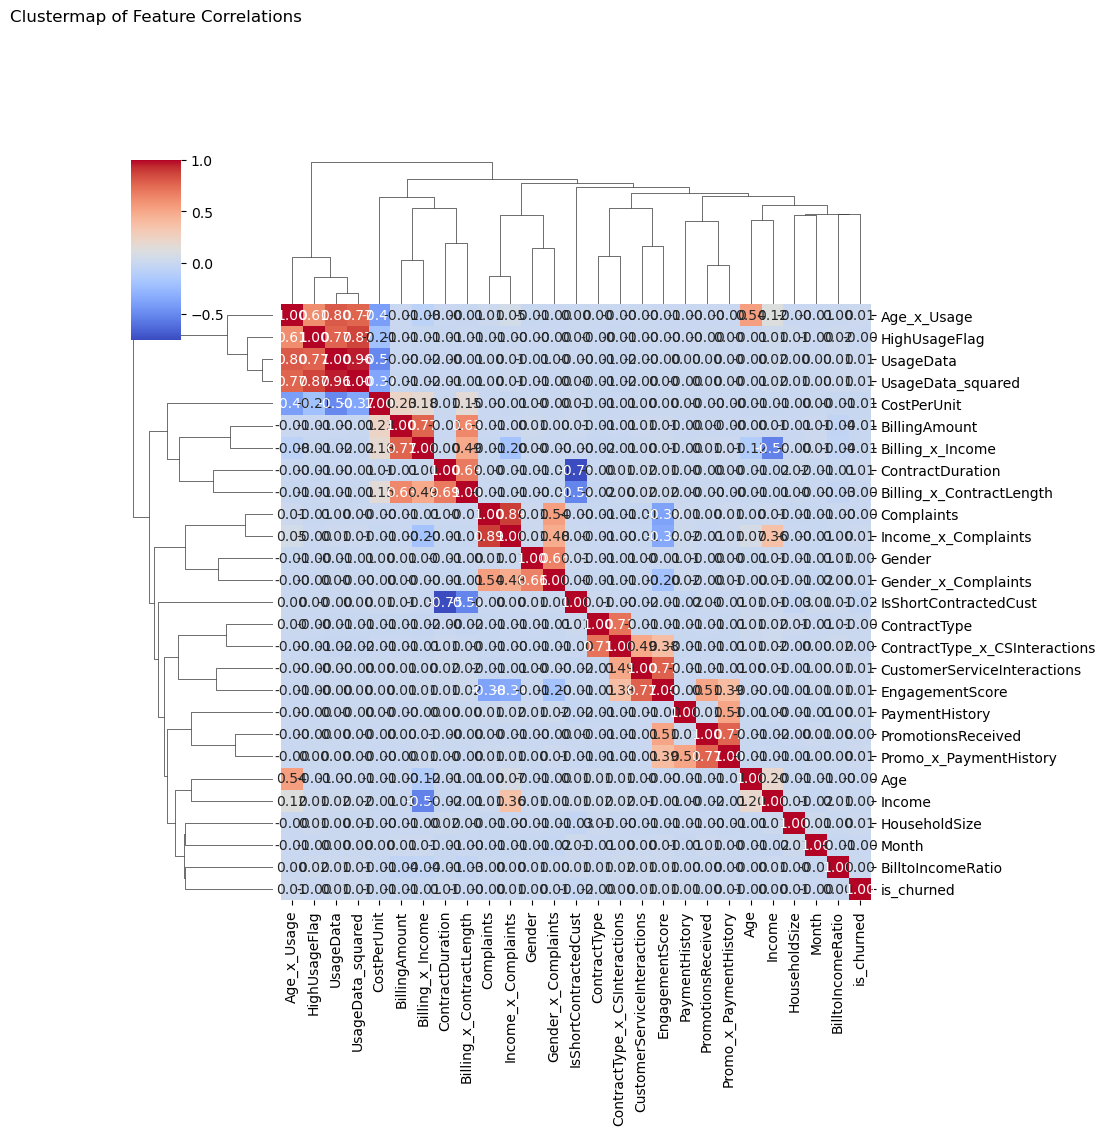

In [210]:
plt.figure(figsize=(12, 10))
clustermap = sns.clustermap(df_feature_eng.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Clustermap of Feature Correlations", pad=100)
plt.show()

In [212]:
# Save the data into processed folder
df_feature_eng.to_csv('../data/processed/churn_data_feat_eng_1.csv', index=False)